<a href="https://colab.research.google.com/github/Developer-Abnam/machine-learning-zoomcamp-2025-solutions/blob/main/4_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EVALUATION METRICS _ ABDULSAMAD NURADEEN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, auc
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
!wget $data

--2025-10-21 07:20:02--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.01s   

2025-10-21 07:20:02 (6.52 MB/s) - ‘course_lead_scoring.csv’ saved [80876/80876]



In [3]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


# Data Preparation
Check if the missing values are presented in the features.

If there are missing values:

+ For caterogiral features, replace them with 'NA'

+ For numerical features, replace with with 0.0

In [4]:
df.isnull().sum()

,0
lead_source,128
industry,134
number_of_courses_viewed,0
annual_income,181
employment_status,100
location,63
interaction_count,0
lead_score,0
converted,0


In [5]:
df_filled = df.copy()

categorical_columns = df_filled.select_dtypes(include='object').columns.tolist()
numerical_columns = df_filled.select_dtypes(include='number').columns.tolist()

if categorical_columns:
    df_filled[categorical_columns] = df_filled[categorical_columns].fillna('NA')

if numerical_columns:
    df_filled[numerical_columns] = df_filled[numerical_columns].fillna(0.0)

Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with random_state=1

In [6]:
df_train_full, df_test = train_test_split(df_filled, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

# Question 1: ROC AUC feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
+ Use the training dataset for that
+ If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

+ `lead_score`
+ `number_of_courses_viewed`
+ `interaction_count`
+ `annual_income`

In [7]:
target='converted'
X_train_full, y_train_full = df_train_full.drop([target], axis=1).copy(), df_train_full[target].copy()
X_train, y_train = df_train.drop([target], axis=1).copy(), df_train[target].copy()
X_val, y_val = df_val.drop([target], axis=1).copy(), df_val[target].copy()
X_test, y_test = df_test.drop([target], axis=1).copy(), df_test[target].copy()
columns = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']
for col in columns:
  roc_auc = roc_auc_score(y_train, df_train[col])
  print(f"Variable: {col}: roc_auc: {roc_auc if roc_auc >= 0.5 else roc_auc_score(y_train, -df_train[col])}")

Variable: lead_score: roc_auc: 0.6144993577250176
Variable: number_of_courses_viewed: roc_auc: 0.7635680590007088
Variable: interaction_count: roc_auc: 0.738270176293409
Variable: annual_income: roc_auc: 0.5519578313253012


# Question 2: Training the model
Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:
```
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```
What's the AUC of this model on the validation dataset? (round to 2 digits)
+ 0.32
+ 0.52
+ 0.72
+ 0.92

# One-Hot-Encoding

In [9]:
numerical_cols = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
categorical_cols = ['lead_source', 'industry', 'employment_status', 'location']

train_full_dicts = df_train_full[numerical_cols + categorical_cols].to_dict(orient='records')
train_dicts = df_train[numerical_cols + categorical_cols].to_dict(orient='records')
val_dicts = df_val[numerical_cols + categorical_cols].to_dict(orient='records')
test_dicts = df_test[numerical_cols + categorical_cols].to_dict(orient='records')

dv = DictVectorizer(sparse=False).set_output(transform='pandas').fit(train_dicts)

X_train_full = dv.transform(train_full_dicts)
X_train = dv.transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

X_train.head(5)

,annual_income,employment_status=NA,employment_status=employed,employment_status=self_employed,employment_status=student,employment_status=unemployed,industry=NA,industry=education,industry=finance,industry=healthcare,...,lead_source=social_media,location=NA,location=africa,location=asia,location=australia,location=europe,location=middle_east,location=north_america,location=south_america,number_of_courses_viewed
0,95543.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
1,54924.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,77352.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,34600.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
4,43615.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Logistic Regression**

In [10]:
log_rig = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
log_rig.fit(X_train, y_train)
y_pred_val = log_rig.predict_proba(X_val)[:, 1]
round(roc_auc_score(y_val, y_pred_val), 2)

np.float64(0.82)

# Question 3: Precision and Recall
Now let's compute precision and recall for our model.

+ Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
+ For each threshold, compute precision and recall
+ Plot them

At which threshold precision and recall curves intersect?
+ 0.145
+ 0.345
+ 0.545
+ 0.745

/tmp/ipython-input-1028489276.py:16: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP+FP)


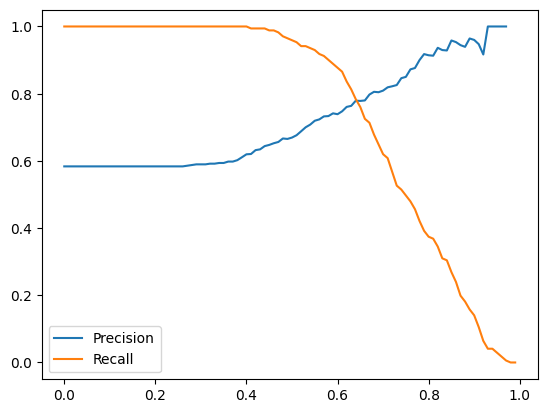

In [12]:
scores = []

for t in np.arange(0, 1, 0.01):
    predictions_true = y_pred_val >= t
    predictions_false = y_pred_val < t
    actual_true = y_val == 1
    actual_false = y_val == 0

    TN = (predictions_false & actual_false).sum()
    FP = (predictions_true & actual_false).sum()
    FN = (predictions_false & actual_true).sum()
    TP = (predictions_true & actual_true).sum()
    confusion_table = np.array([[TN, FP],
                                [FN, TP]])

    precision = TP / (TP+FP)
    recall = TP / (TP+FN)

    scores.append([t, precision, recall])

df_scores = pd.DataFrame(data=scores, columns=["threshold", "precision", "recall"])
plt.plot(df_scores["threshold"],df_scores["precision"], label="Precision")
plt.plot(df_scores["threshold"],df_scores["recall"], label="Recall")
plt.legend()

In [13]:
df_scores.iloc[np.argmin(np.abs(df_scores.precision - df_scores.recall))]

,64
threshold,0.640000
precision,0.779070
recall,0.783626


# Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$F_1 = 2\frac{P.R}{P+R}$


Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?
+ 0.14
+ 0.34
+ 0.54
+ 0.74

In [14]:
df_scores["f1"] = 2*(df_scores.precision * df_scores.recall) / (df_scores.precision + df_scores.recall)
df_scores[df_scores.f1 == df_scores.f1.max()]

,threshold,precision,recall,f1
57,0.57,0.732394,0.912281,0.8125


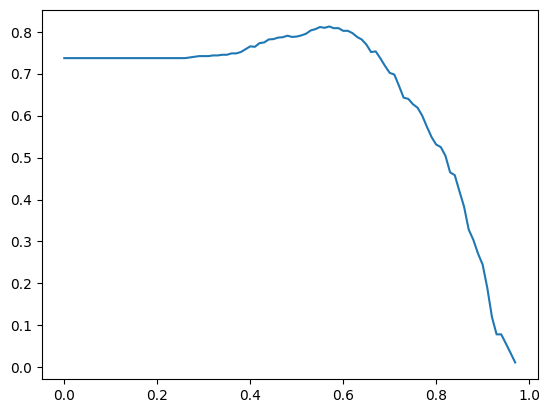

In [ ]:
plt.plot(df_scores["threshold"], df_scores["f1"])

# Question 5: 5-Fold CV
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:
```
KFold(n_splits=5, shuffle=True, random_state=1)
```
+ Iterate over different folds of `df_full_train`
+ Split the data into train and validation
+ Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
+ Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

+ 0.0001
+ 0.006
+ 0.06
+ 0.26

In [15]:
def train(X, y):
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X, y)
    return model

def predict(X, model):
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
aucs = []

for train_idx, val_idx in kfold.split(X_train_full, y_train_full):
    train_X = X_train_full.iloc[train_idx]
    val_X = X_train_full.iloc[val_idx]

    train_y = y_train_full.iloc[train_idx]
    val_y = y_train_full.iloc[val_idx]

    model = train(train_X, train_y)
    y_pred_val = predict(val_X, model)

    auc = roc_auc_score(val_y, y_pred_val)
    aucs.append(auc)

print('auc = %0.3f ± %0.3f' % (np.mean(aucs), np.std(aucs)))

auc = 0.822 ± 0.036


# Question 6: Hyperparameter Tuning
Now let's use 5-Fold cross-validation to find the best parameter `C`.

+ Iterate over the following `C` values: `[0.000001, 0.001, 1]`
+ Initialize `KFold` with the same parameters as previously
+ Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
+ Compute the `mean` score as well as the `std` (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

+ 0.000001
+ 0.001
+ 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [ ]:
def train(X, y, C):
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X, y)
    return model

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for C in [0.000001, 0.001, 1]:
    aucs = []

    for train_idx, val_idx in kfold.split(X_train_full, y_train_full):
        train_X = X_train_full.iloc[train_idx]
        val_X = X_train_full.iloc[val_idx]

        train_y = y_train_full.iloc[train_idx]
        val_y = y_train_full.iloc[val_idx]

        model = train(train_X, train_y, C=C)
        y_pred_val = predict(val_X, model)

        auc = roc_auc_score(val_y, y_pred_val)
        aucs.append(auc)
    print('C=%s, auc = %0.3f ± %0.3f' % (C, np.mean(aucs), np.std(aucs)))

C=1e-06, auc = 0.560 ± 0.024
C=0.001, auc = 0.867 ± 0.029
C=1, auc = 0.822 ± 0.036
